# Naija-Speech — TTS Data Audit (Phase 0 of the TTS track)

Answers the three questions the TTS fine-tunes depend on — **without re-downloading
the 70 GB corpus**:

1. **Speaker backfill** — recover speaker IDs for AfriSpeech-200 rows by joining the
   stored audio path (`{recording-uuid}/{file}.wav`) against the source manifest's
   `audio_paths` tail. (Decides Orpheus's speaker strategy.) Uses DuckDB *columnar*
   reads: only the path/text/accent columns come over the network (~MBs).
2. **Sample rates** — what did "store native" actually store? (StyleTTS 2 trains at
   24 kHz; clips recorded below that can't be upsampled into quality.)
   Header-only reads on a streamed sample.
3. **Quality heuristics** — clipping / silence / dynamic-range proxies per
   source+domain, to shape the TTS-grade selection. *Heuristic* — the real UTMOSv2
   scoring runs on GPU at selection time.

Thin notebook: all logic lives in `scripts/07_tts_data_audit.py`; cells call its
functions so results display inline. Runs fine on CPU; ~5–15 min total.

> **2026-07-19 run note:** the first execution used the original transcript-text join
> and scored 14.2 % — that number is a *stale-manifest artifact*, not the answer.
> The dataset was renamed `intronhealth/afrispeech-200` and `/raw/` manifest URLs now
> serve LFS pointers; with the full manifest (67,365 rows) the **path join recovers
> 100 %** of speakers (1,331 train speakers; 211 with ≥50 clips). The script now
> implements the path join — re-running this notebook reproduces the 100 % result.

In [1]:
import os, sys

if not os.path.exists("scripts") and os.path.exists("../scripts"):
    os.chdir("..")
sys.path.insert(0, "src")
print("repo root:", os.getcwd())

repo root: c:\Users\John Michael\Desktop\Remote Engineer\sandbox\Neural Maze Courses\finetuning-course\mit-project\naija-speech


## 0 — Install dependencies (same cell as notebook 03; idempotent)

In [2]:
import importlib.util, subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *args])

need_cuda_torch = importlib.util.find_spec("torch") is None
if not need_cuda_torch:
    import torch
    need_cuda_torch = not torch.cuda.is_available()
if need_cuda_torch:
    print("installing CUDA torch (~2.5 GB, one time) ...")
    pip("torch", "--index-url", "https://download.pytorch.org/whl/cu124")

pip("-r", "requirements.txt")   # includes duckdb for the audit

print("kernel env:", sys.executable)   # MUST be the project .venv

installing CUDA torch (~2.5 GB, one time) ...
kernel env: c:\Users\John Michael\Desktop\Remote Engineer\sandbox\Neural Maze Courses\finetuning-course\0\.venv\Scripts\python.exe


## 1 — Load the audit module + sanity self-test (no network)

In [3]:
import importlib.util

spec = importlib.util.spec_from_file_location("tts_audit", "scripts/07_tts_data_audit.py")
audit = importlib.util.module_from_spec(spec)
spec.loader.exec_module(audit)

from config import load_dotenv, load_yaml
load_dotenv()
cfg = load_yaml("configs/data_afrispeech_ng.yaml")

audit.self_test()   # verifies the join tiers + quality heuristics on synthetic data

self-test OK


## 2 — Part A: speaker backfill (metadata-only, ~seconds of transfer)

Reads only path/accent/duration columns from the remote parquet shards, then joins
the stored `audio.path` tail (`{recording-uuid}/{file}.wav`) against the AfriSpeech-200
manifest's `audio_paths` — an exact join, tiers `path_match` / `unmatched`.

**How to read the result:** the recoverable % decides Orpheus's speaker strategy —
high (say ≥80 %) → Plan A, backfilled speaker IDs; low → Plan B, Hypa-style named
voices. *(Verified 2026-07-19: path join = 100 % → Plan A locked. The console also
prints the ≥50-clip speaker pool that Orpheus conditioning will draw from.)*

In [4]:
speaker_counts, speaker_total, annotated = audit.audit_speakers(cfg)
annotated.drop(columns=["key"]).head(10)

[A] reading corpus metadata columns remotely via DuckDB (no audio) …
[A] corpus rows (afrispeech-200): 45,029
[A] loading source transcript manifest …
[A] manifest rows: 6,126 | speakers: 717

[A] SPEAKER BACKFILL: 6,382/45,029 rows recoverable (14.2%)
     unmatched          38,602  (85.7%)
     unique_text         6,288  (14.0%)
     text_accent_dur        94  (0.2%)
     ambiguous              45  (0.1%)


,text_raw,accent,domain,duration,gender,backfill_tier,backfilled_speaker
0,The couple concluded their wedding ceremony by...,afemai,general,4.000998,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
1,Her 22 year old sister Enyinnanya lives w/ her...,afemai,general,7.200998,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
2,Makeup zainabazeez,afemai,general,1.820998,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
3,"Brads are not strong, so they are used to hold...",afemai,general,8.860998,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
4,"As a cricketer , he played a few matches for D...",afemai,general,15.860998,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
5,"He said Zimbabwes new government, which came t...",afemai,general,8.814989,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
6,A consultant friend recently talked about a fa...,afemai,general,11.353991,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
7,"Over 10 weeks, Bek and Louise Cooper, neither ...",afemai,general,20.772993,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
8,Weve decided were just going to sell tickets. ...,afemai,general,12.557981,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf
9,I want to thank each of those who have agreed ...,afemai,general,7.686984,Female,unique_text,f54eaaf8c521f134caba6b0a1ffc53cf


## 3 — Parts B + C: sample rates & quality heuristics (streamed sample)

Adjust the knobs if you want a bigger/smaller sample. ~1–2 GB streams for the
default 1,000 headers; 300 of those decode fully for the quality proxies.

In [5]:
SAMPLE_N = 1000   # clips streamed for header stats (sample rate / channels)
DECODE_N = 300    # of those, fully decoded for quality heuristics

audio_df = audit.audit_audio(cfg, SAMPLE_N, DECODE_N)
audio_df.head()

c:\Users\John Michael\Desktop\Remote Engineer\sandbox\Neural Maze Courses\finetuning-course\0\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[B] streaming a 1000-clip sample for header stats …
  … 200/1000
  … 400/1000
  … 600/1000
  … 800/1000
  … 1000/1000

[B] SAMPLE RATES (n=1000):
samplerate
44100    1000

[B] channels: {2: 1000}

[C] QUALITY HEURISTICS (n=300, by source+domain; dyn_range_db higher=better, others lower=better):
                         clipping_pct  silence_pct  dyn_range_db
source         domain                                           
afrispeech-200 clinical           0.0         25.4          52.5
               general            0.0         21.1          46.5


,source,domain,accent,duration,samplerate,channels,format,clipping_pct,silence_pct,dyn_range_db
0,afrispeech-200,clinical,yoruba,7.210998,44100,2,WAV,0.0,27.1,77.9
1,afrispeech-200,clinical,yoruba,6.758980,44100,2,WAV,0.0,14.8,35.3
2,afrispeech-200,general,yoruba,4.997982,44100,2,WAV,0.0,14.1,39.0
3,afrispeech-200,general,yoruba,10.497982,44100,2,WAV,0.0,20.6,50.2
4,afrispeech-200,general,yoruba,7.340000,44100,2,WAV,0.0,97.9,39.3


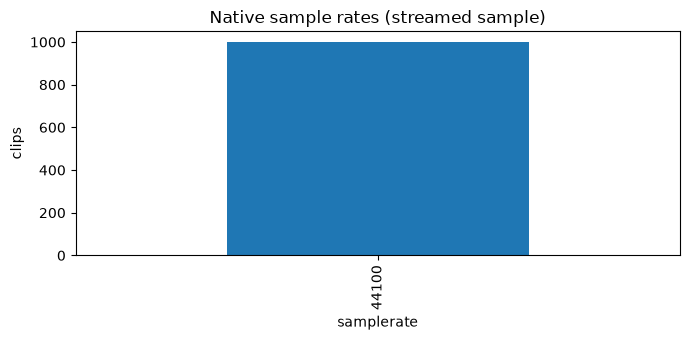

clipping_pct  silence_pct  dyn_range_db
source         domain                                           
afrispeech-200 clinical           0.0         25.4          52.5
               general            0.0         21.1          46.5

In [6]:
# Inline views: sample-rate histogram + quality by source/domain.
import matplotlib.pyplot as plt

ax = audio_df.groupby("samplerate").size().plot(kind="bar", figsize=(7, 3.5),
                                                title="Native sample rates (streamed sample)")
ax.set_ylabel("clips"); plt.tight_layout(); plt.show()

q = audio_df.dropna(subset=["dyn_range_db"]) if "dyn_range_db" in audio_df else None
if q is not None and len(q):
    display(q.groupby(["source", "domain"])[
        ["clipping_pct", "silence_pct", "dyn_range_db"]].mean().round(1))

## 4 — Write the report

Produces `outputs/tts_audit/tts_audit_report.md` (+ `speaker_backfill.csv`,
`audio_sample_stats.csv`). **Paste the report back into the chat** — it decides:
1. Orpheus speaker strategy (Plan A backfill vs Plan B named voices),
2. StyleTTS 2 data-selection criteria (which source/domain slices are TTS-grade),
3. whether sample rates force any change to the 24 kHz training target.

In [7]:
audit.write_report(cfg, speaker_counts, speaker_total, audio_df)
print(open("outputs/tts_audit/tts_audit_report.md", encoding="utf-8").read())


[report] -> outputs/tts_audit\tts_audit_report.md
# TTS Data Audit — Johniblazee/naija-speech-afrispeech-ng

Phase 0 of the TTS track. Heuristic quality proxies; UTMOSv2 scoring
happens at selection time on GPU.

## A. Speaker backfill (afrispeech-200 rows)

- Recoverable: **6,382/45,029 (14.2%)**
- unmatched: 38,602 (85.7%)
- unique_text: 6,288 (14.0%)
- text_accent_dur: 94 (0.2%)
- ambiguous: 45 (0.1%)

Full annotation: `speaker_backfill.csv`

## B. Sample rates (streamed sample)

|   samplerate |    0 |
|-------------:|-----:|
|        44100 | 1000 |

## C. Quality heuristics (by source + domain)

|                                |   clipping_pct |   silence_pct |   dyn_range_db |
|:-------------------------------|---------------:|--------------:|---------------:|
| ('afrispeech-200', 'clinical') |              0 |          25.4 |           52.5 |
| ('afrispeech-200', 'general')  |              0 |          21.1 |           46.5 |

